In [1]:
# 평가에 필요한 모든 라이브러리를 불러옵니다
# 이미지 모델(openfake)과 영상 모델(vidprom) 경로를 각각 설정합니다

import os
import random
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

BASE = r"C:\Users\user\Desktop\deepfake-detector"

CONFIG = {
    # 공통
    "model_name"        : "google/vit-base-patch16-224-in21k",
    "batch_size"        : 32,
    "num_workers"       : 0,        # Windows 환경 DataLoader 오류 방지
    "seed"              : 42,

    # 이미지 모델 (openfake)
    "image_data_dir"    : os.path.join(BASE, "data", "openfake"),
    "image_model_path"  : os.path.join(BASE, "models", "openfake", "best_model.pth"),
    "image_history_path": os.path.join(BASE, "models", "openfake", "history.json"),

    # 영상 모델 (vidprom) - 프레임 추출 결과 폴더 사용
    "video_frame_dir"   : os.path.join(BASE, "data", "vidprom", "frames"),
    "video_model_path"  : os.path.join(BASE, "models", "vidprom", "best_model.pth"),
    "video_history_path": os.path.join(BASE, "models", "vidprom", "history.json"),
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")
print("설정 완료!")

device: cuda
설정 완료!


In [2]:
# 이미지/영상 프레임 모두 동일한 Dataset 클래스를 재사용합니다
# ViT 입력 규격(224x224, ImageNet 정규화)에 맞게 전처리합니다
# 학습 때와 동일한 정규화 값을 사용해야 평가가 정확합니다

processor = ViTImageProcessor.from_pretrained(CONFIG["model_name"])

# 평가용 transform - augmentation 없이 resize + 정규화만
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

class EvalDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = self.file_list[idx]
        label = self.labels[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            # 손상된 이미지는 검은 이미지로 대체
            img = Image.new("RGB", (224, 224), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, label

print("Dataset 클래스 및 transform 정의 완료!")

Dataset 클래스 및 transform 정의 완료!


In [3]:
# 모델과 DataLoader를 받아서 예측을 수행하고 지표를 계산합니다
# accuracy, F1, AUC, confusion matrix를 한번에 출력합니다
# history.json이 있으면 학습 곡선(loss/accuracy)도 함께 시각화합니다

def evaluate_model(model, loader, model_label="모델"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(loader):
            imgs   = imgs.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=imgs)
            probs   = torch.softmax(outputs.logits, dim=1)[:, 1]  # Fake 클래스 확률
            preds   = outputs.logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            # 10% 단위로 진행 상황 출력
            total = len(loader)
            if (batch_idx + 1) % max(1, total // 10) == 0:
                print(f"  [{batch_idx+1}/{total}] 배치 처리 중...")

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="weighted")
    auc = roc_auc_score(all_labels, all_probs)
    cm  = confusion_matrix(all_labels, all_preds)

    print(f"\n{'='*50}")
    print(f"  {model_label} 평가 결과")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  AUC      : {auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=["Real", "Fake"]))
    print(f"  Confusion Matrix:")
    print(f"  {cm}")
    print(f"  (행=실제, 열=예측 / 순서: Real, Fake)")

    return {"accuracy": acc, "f1": f1, "auc": auc,
            "preds": all_preds, "labels": all_labels, "probs": all_probs}


def plot_history(history_path, model_label="모델"):
    # history.json을 읽어서 epoch별 loss/accuracy 그래프를 출력합니다
    if not os.path.exists(history_path):
        print(f"  history.json 없음 - 학습 곡선 스킵")
        return

    with open(history_path, "r") as f:
        history = json.load(f)

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{model_label} - 학습 곡선", fontsize=13)

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   marker="o")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history["train_acc"], label="Train Acc", marker="o")
    axes[1].plot(epochs, history["val_acc"],   label="Val Acc",   marker="o")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

print("평가 함수 정의 완료!")

평가 함수 정의 완료!


[이미지 모델] 데이터 로드 중...
  real: 50000장 / fake: 78444장
  테스트셋: 10000장

[이미지 모델] best_model.pth 로드 중...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델 로드 완료! 평가 시작...



C:\Users\user\AppData\Local\Temp\ipykernel_13300\298527733.py:82: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13300\298527733.py:82: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13300\298527733.py:82: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13300\298527733.py:82: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13300\298527733.py:82: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13300\298527733.py:82: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu 

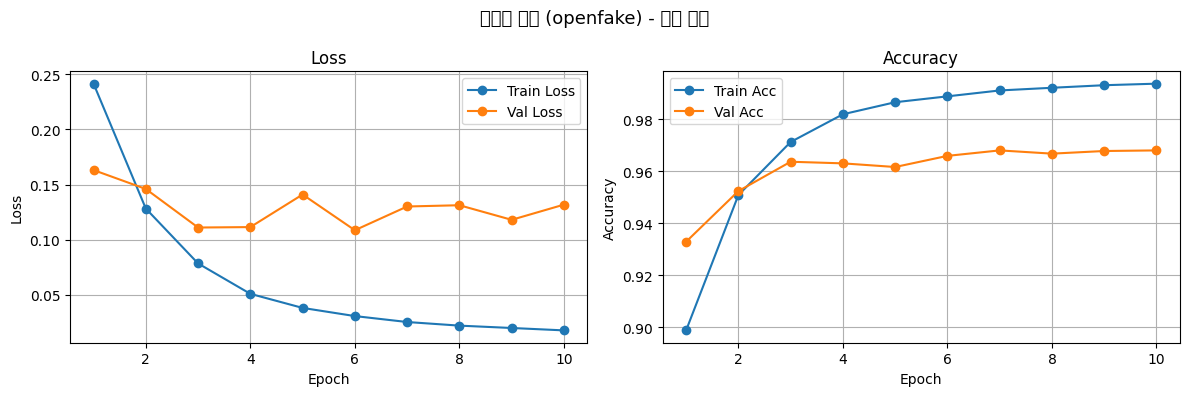

  [31/313] 배치 처리 중...
  [62/313] 배치 처리 중...
  [93/313] 배치 처리 중...
  [124/313] 배치 처리 중...
  [155/313] 배치 처리 중...
  [186/313] 배치 처리 중...
  [217/313] 배치 처리 중...
  [248/313] 배치 처리 중...
  [279/313] 배치 처리 중...
  [310/313] 배치 처리 중...

  이미지 모델 (openfake) 평가 결과
  Accuracy : 0.9904 (99.04%)
  F1 Score : 0.9904
  AUC      : 0.9989

  Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      5000
        Fake       0.99      0.99      0.99      5000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

  Confusion Matrix:
  [[4933   67]
 [  29 4971]]
  (행=실제, 열=예측 / 순서: Real, Fake)


In [4]:
# openfake 데이터셋의 real/fake 이미지를 불러옵니다
# best_model.pth를 로드하고 테스트셋으로 성능을 측정합니다
# history.json이 있으면 학습 곡선도 함께 출력합니다

print("[이미지 모델] 데이터 로드 중...")
random.seed(CONFIG["seed"])

real_dir  = os.path.join(CONFIG["image_data_dir"], "real")
fake_dir  = os.path.join(CONFIG["image_data_dir"], "fake")

real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]
fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))]

print(f"  real: {len(real_files)}장 / fake: {len(fake_files)}장")

# 클래스 불균형 방지 - 적은 쪽 기준으로 언더샘플링
min_count  = min(len(real_files), len(fake_files))
real_files = random.sample(real_files, min_count)
fake_files = random.sample(fake_files, min_count)

all_files  = real_files + fake_files
all_labels = [0] * min_count + [1] * min_count  # 0=Real, 1=Fake

# 학습 때와 동일한 split으로 test셋만 분리
_, test_files, _, test_labels = train_test_split(
    all_files, all_labels,
    test_size=0.1, random_state=CONFIG["seed"], stratify=all_labels
)
print(f"  테스트셋: {len(test_files)}장")

image_test_loader = DataLoader(
    EvalDataset(test_files, test_labels, transform=eval_transform),
    batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"]
)

# 모델 로드
print("\n[이미지 모델] best_model.pth 로드 중...")
image_model = ViTForImageClassification.from_pretrained(
    CONFIG["model_name"], num_labels=2, ignore_mismatched_sizes=True
)
image_model.load_state_dict(torch.load(CONFIG["image_model_path"], map_location=device))
image_model.to(device)
print("모델 로드 완료! 평가 시작...\n")

plot_history(CONFIG["image_history_path"], model_label="이미지 모델 (openfake)")
image_results = evaluate_model(image_model, image_test_loader, model_label="이미지 모델 (openfake)")

In [7]:
# 프레임 추출 결과 폴더(frames/real, frames/fake)에서 이미지를 불러옵니다
# best_model.pth를 로드하고 테스트셋으로 성능을 측정합니다
# 영상 모델도 프레임 단위 이미지로 학습했기 때문에 동일한 방식으로 평가합니다

print("[영상 모델] 데이터 로드 중...")
random.seed(CONFIG["seed"])

v_real_dir  = os.path.join(CONFIG["video_frame_dir"], "real")
v_fake_dir  = os.path.join(CONFIG["video_frame_dir"], "fake")

v_real_files = [os.path.join(v_real_dir, f) for f in os.listdir(v_real_dir)
                if f.lower().endswith(".jpg")]
v_fake_files = [os.path.join(v_fake_dir, f) for f in os.listdir(v_fake_dir)
                if f.lower().endswith(".jpg")]

print(f"  real 프레임: {len(v_real_files)}장 / fake 프레임: {len(v_fake_files)}장")

# 클래스 균형 맞추기
v_min        = min(len(v_real_files), len(v_fake_files))
v_real_files = random.sample(v_real_files, v_min)
v_fake_files = random.sample(v_fake_files, v_min)

v_all_files  = v_real_files + v_fake_files
v_all_labels = [0] * v_min + [1] * v_min  # 0=Real, 1=Fake

_, v_test_files, _, v_test_labels = train_test_split(
    v_all_files, v_all_labels,
    test_size=0.1, random_state=CONFIG["seed"], stratify=v_all_labels
)
print(f"  테스트셋: {len(v_test_files)}장")

video_test_loader = DataLoader

[영상 모델] 데이터 로드 중...
  real 프레임: 44996장 / fake 프레임: 12521장
  테스트셋: 2505장


In [ ]:
# 이미지 모델과 영상 모델의 성능 지표를 나란히 비교합니다
# Accuracy, F1, AUC를 막대 그래프로 시각화합니다
# 포트폴리오 정리 시 이 결과를 그대로 활용할 수 있습니다

print("\n" + "="*60)
print("  두 모델 성능 비교 요약")
print("="*60)
print(f"  {'지표':<12} {'이미지 모델':>15} {'영상 모델':>15}")
print(f"  {'-'*42}")
print(f"  {'Accuracy':<12} {image_results['accuracy']:>14.4f} {video_results['accuracy']:>14.4f}")
print(f"  {'F1 Score':<12} {image_results['f1']:>14.4f} {video_results['f1']:>14.4f}")
print(f"  {'AUC':<12} {image_results['auc']:>14.4f} {video_results['auc']:>14.4f}")
print("="*60)

# 막대 그래프 비교
metrics      = ["Accuracy", "F1 Score", "AUC"]
image_scores = [image_results["accuracy"], image_results["f1"], image_results["auc"]]
video_scores = [video_results["accuracy"], video_results["f1"], video_results["auc"]]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, image_scores, width, label="이미지 모델 (openfake)", color="steelblue")
bars2 = ax.bar(x + width/2, video_scores, width, label="영상 모델 (vidprom)",   color="coral")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

ax.set_title("이미지 모델 vs 영상 모델 성능 비교", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n평가 완료!")